In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import pickle
import corner
from pathlib import Path
import math

In [2]:

tmids_outerdf_path = Path("/Users/johnnymoynihan/Documents/GitHub/batman_mcmc/kepler9_holczer_outer.csv")
tmids_outer_df = pd.read_csv(tmids_outerdf_path)
tmids_outer = tmids_outer_df['tmid']
tmid0_outer = tmids_outer[0]
tmids_linephem = tmids_outer_df['tn']

print(f"tmids outer : {tmids_outer}")
print(f"linear ephemerus tmids outer : {tmids_linephem}")

tmids outer : 0      136.306699
1      175.331925
2      214.336663
3      253.313000
4      292.263433
5      331.182548
6      370.072217
7      408.931054
8      447.765862
9      486.578032
10     525.377979
11     564.169732
12     602.959540
13     641.753932
14     680.562768
15     758.237038
16     797.113097
17     836.022072
18     874.963894
19     913.935717
20     952.933303
21     991.954432
22    1031.000906
23    1109.117190
24    1148.184707
25    1187.257640
26    1226.332171
27    1265.405382
28    1304.479358
29    1343.553194
30    1382.624808
31    1421.698852
32    1460.769495
33    1499.835275
34    1538.903834
35    1577.962322
Name: tmid, dtype: float64
linear ephemerus tmids outer : 0      135.896213
1      174.846022
2      213.795830
3      252.745639
4      291.695447
5      330.645256
6      369.595064
7      408.544873
8      447.494681
9      486.444490
10     525.394298
11     564.344107
12     603.293915
13     642.243724
14     681.193532
15     759

In [3]:
#load in curves and info from mcmc

In [17]:
with open("mcmc_curves_kepler9c.pkl", "rb") as f:
    mcmcresults = pickle.load(f)
    
curves = mcmcresults["curves"]
info = mcmcresults["info"]
ncurves = info["ncurves"]
tmidi_calc = []
for i, curve in enumerate(curves):
    tmidi_i = curve["tmidi"]
    tmidi_calc.append(tmidi_i)
#print(tmidi_calc - tmids_linephem)


In [33]:
print(tmids_nonlinear)


[[0.4103189  0.48498547 0.54043766 ... 0.69503603 0.81263461 0.92163971]
 [0.41039526 0.48486589 0.54040423 ... 0.69499704 0.81266275 0.9215894 ]
 [0.4103717  0.48491253 0.5404511  ... 0.69506363 0.81264046 0.92159339]
 ...
 [0.41034281 0.48508369 0.54048647 ... 0.69505571 0.81268241 0.92158717]
 [0.4104146  0.48494154 0.54046114 ... 0.69500508 0.81268718 0.92164117]
 [0.41041004 0.48488035 0.54040076 ... 0.69498518 0.81267383 0.9215695 ]]


In [18]:
### load in nonlinear mcmc

In [57]:
nonlinear_posterior = az.from_netcdf("arviz_kepler9c_nonlinear.nc")
burnin = info["burnin"]
nonlinear_posterior = nonlinear_posterior.sel(draw=slice(burnin, None))
nonlinear_results = mcmcresults["nonlinear_results"]
tmids_nonlinear = nonlinear_results["nonlinear_psi_samps"] 
print(nonlinear_posterior.posterior)
print(nonlinear_posterior.sample_stats)
az.summary(nonlinear_posterior)

<xarray.Dataset> Size: 5MB
Dimensions:   (chain: 12, draw: 10000)
Coordinates:
  * chain     (chain) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * draw      (draw) int64 80kB 30000 30001 30002 30003 ... 39997 39998 39999
Data variables:
    p         (chain, draw) float64 960kB ...
    b         (chain, draw) float64 960kB ...
    ln_rho_s  (chain, draw) float64 960kB ...
    q1        (chain, draw) float64 960kB ...
    q2        (chain, draw) float64 960kB ...
Attributes:
    created_at:                 2025-11-25T03:52:33.765517+00:00
    arviz_version:              0.22.0
    inference_library:          emcee
    inference_library_version:  3.1.6
<xarray.Dataset> Size: 1MB
Dimensions:  (chain: 12, draw: 10000)
Coordinates:
  * chain    (chain) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * draw     (draw) int64 80kB 30000 30001 30002 30003 ... 39997 39998 39999
Data variables:
    lp       (chain, draw) float64 960kB ...
Attributes:
    created_at:                 2025-11-25T03:52:33.754060+00:

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.077,0.001,0.076,0.078,0.000,0.000,948.0,1996.0,1.01
b,0.764,0.006,0.754,0.775,0.000,0.000,1152.0,3037.0,1.01
ln_rho_s,7.271,0.027,7.225,7.313,0.001,0.000,1278.0,4354.0,1.01
q1,0.388,0.051,0.294,0.481,0.002,0.001,889.0,2147.0,1.01
q2,0.285,0.144,0.100,0.544,0.005,0.003,963.0,1667.0,1.01


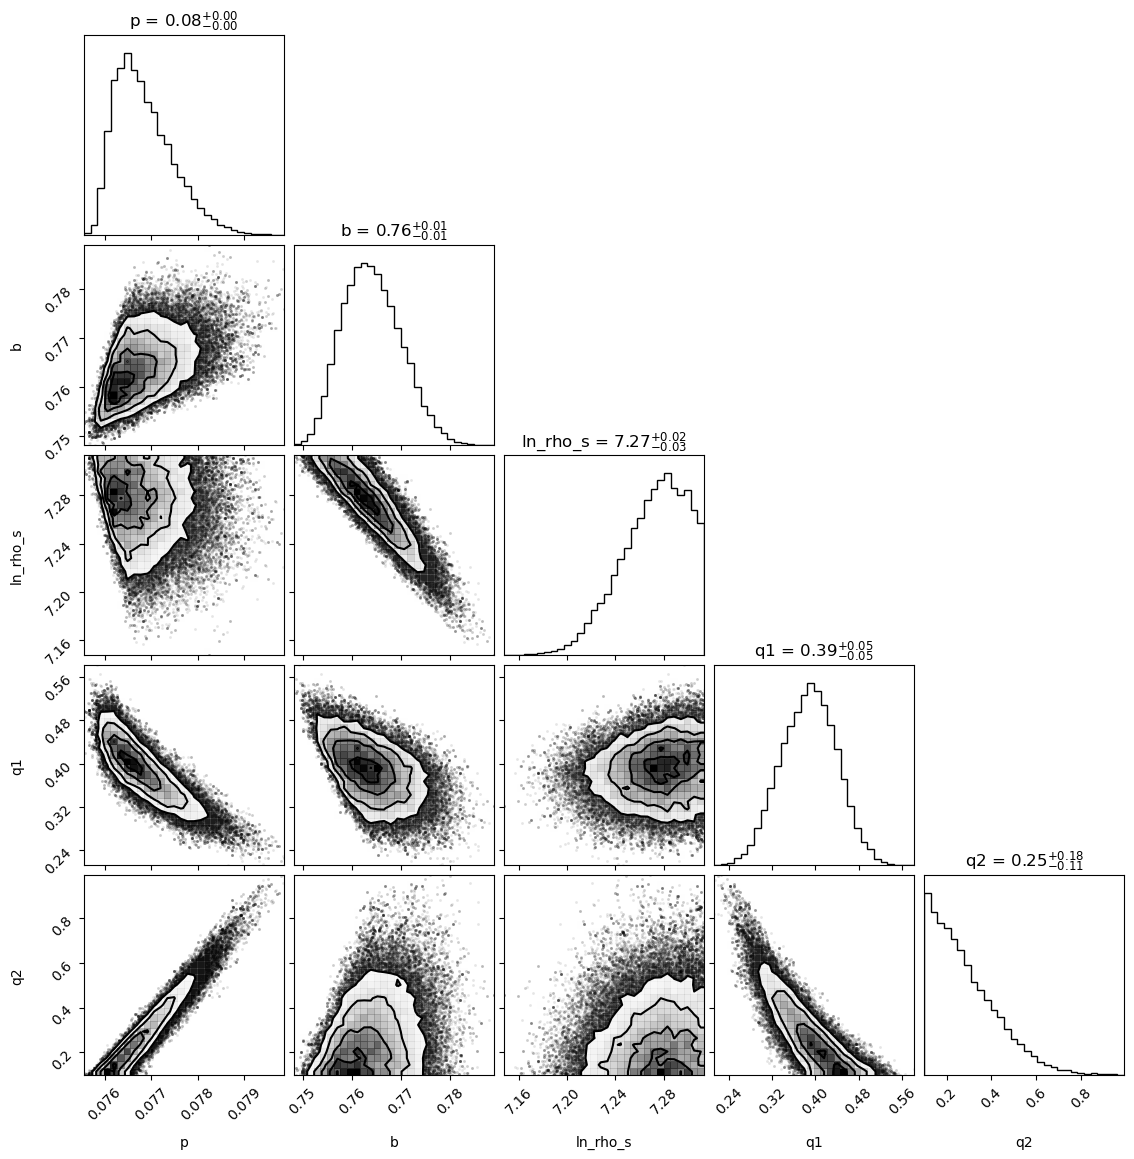

In [58]:
ds = nonlinear_posterior.posterior

posterior_flat = ds.to_array().stack(sample=("chain", "draw")).transpose()
samples = posterior_flat.values

param_names = list(ds.data_vars)

fig = corner.corner(
    samples,
    labels=param_names,
    bins=30,
    show_titles=True,
    title_fmt=".2f",
)

plt.show()


In [21]:
#### get median and +/- 1$\sigma$ tmid values from each one

In [22]:


# ###linear calc
# ncurves = info["ncurves"]

# tts_l_median = []
# tts_l_err = []
# for ii in range(0, ncurves):
#     tts_l = np.median(linear_posterior.posterior[f"tmid{ii}"].values)
#     tts_l_median.append(tts_l)
    
    
#     tts_l_quantile = [np.quantile(linear_posterior.posterior[f"tmid{ii}"].values, 0.16),
#                     np.quantile(linear_posterior.posterior[f"tmid{ii}"].values, 0.84)]
    
#     tts_l_err.append(np.array([
#         tts_l - tts_l_quantile[0],
#         tts_l_quantile[1] - tts_l
#     ]))
    
#     print(f"linear: relative tmid{ii} {tts_l}, and 1 sigma {tts_l_err[ii]}")
    

# tts_l_err = np.array(tts_l_err).T



In [23]:
### get tmids from non linear blobs

In [25]:
nonlinear_posterior = az.from_netcdf("arviz_kepler9c_nonlinear.nc")
nonlinear_results = mcmcresults["nonlinear_results"]
tmids_nonlinear = nonlinear_results["nonlinear_psi_samps"] 
print(tmids_nonlinear.shape)

###nonlinear calc
ncurves = info["ncurves"]

tts_l_median = []
tts_l_err = []
for ii in range(0, ncurves):
    tts_l = np.median(tmids_nonlinear[:, ii])
    tts_l_median.append(tts_l)
    
    
    tts_l_quantile = [np.quantile(tmids_nonlinear[:, ii], 0.16),
                    np.quantile(tmids_nonlinear[:, ii], 0.84)]
    
    tts_l_err.append(np.array([
        tts_l - tts_l_quantile[0],
        tts_l_quantile[1] - tts_l
    ]))
    
    print(f"nonlinear: relative tmid{ii} {tts_l}")
    

tts_l_err = np.array(tts_l_err).T





(12000, 36)
nonlinear: relative tmid0 0.4103572971049374
nonlinear: relative tmid1 0.4849612469937483
nonlinear: relative tmid2 0.5404520024378598
nonlinear: relative tmid3 0.5678960297692157
nonlinear: relative tmid4 0.5673948927961874
nonlinear: relative tmid5 0.539916945898824
nonlinear: relative tmid6 0.47639020496094986
nonlinear: relative tmid7 0.3850059223073288
nonlinear: relative tmid8 0.26953068314386996
nonlinear: relative tmid9 0.1332409774711607
nonlinear: relative tmid10 -0.0166390829161287
nonlinear: relative tmid11 -0.174945110365627
nonlinear: relative tmid12 -0.3351977575294427
nonlinear: relative tmid13 -0.4903967472922659
nonlinear: relative tmid14 -0.6315565996221721
nonlinear: relative tmid15 -0.8548562983989427
nonlinear: relative tmid16 -0.9306886692483545
nonlinear: relative tmid17 -0.9712943266120533
nonlinear: relative tmid18 -0.9779763547435323
nonlinear: relative tmid19 -0.9575941806653532
nonlinear: relative tmid20 -0.9063075533895244
nonlinear: relative t

In [26]:
### print relative tmid holczer

In [27]:
tmid_relative_holczer0 = tmids_outer[0] - tmids_linephem[0]
print(tmid_relative_holczer0)

0.410486111111112


In [37]:
tmid_relative_holczer = tmids_outer - tmids_linephem
print(tmid_relative_holczer)


0     0.410486
1     0.485903
2     0.540833
3     0.567361
4     0.567986
5     0.537292
6     0.477153
7     0.386181
8     0.271181
9     0.133542
10   -0.016319
11   -0.174375
12   -0.334375
13   -0.489792
14   -0.630764
15   -0.856111
16   -0.929861
17   -0.970694
18   -0.978681
19   -0.956667
20   -0.908889
21   -0.837569
22   -0.740903
23   -0.524236
24   -0.406528
25   -0.283403
26   -0.158681
27   -0.035278
28    0.088889
29    0.212917
30    0.334722
31    0.458958
32    0.579792
33    0.695764
34    0.814514
35    0.923194
dtype: float64


In [29]:
#### make corner plots, tmids only

In [30]:
print(tmids_nonlinear.shape, len(tmidi_calc), tmids_outer.shape)


(12000, 36) 36 (36,)


36


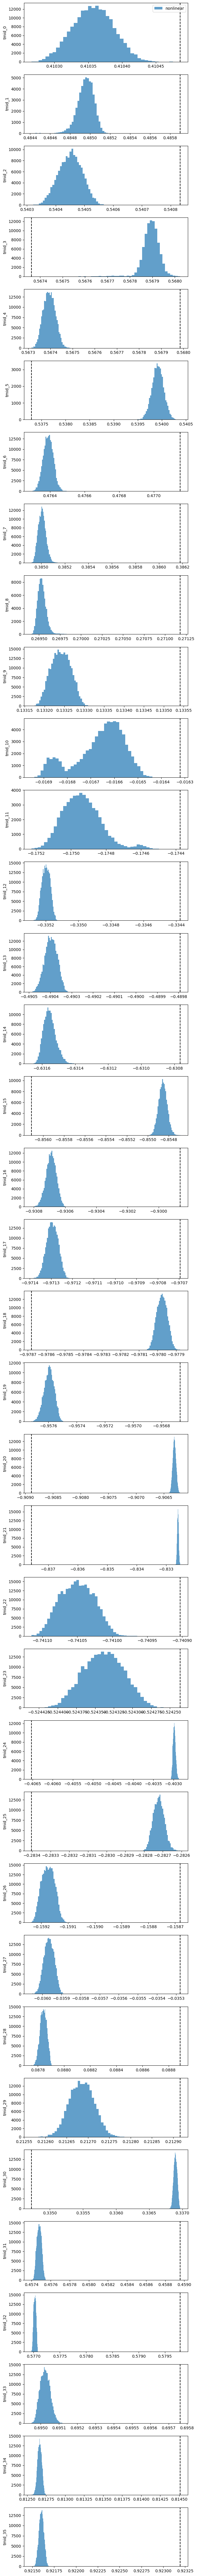

In [31]:
# --- NONLINEAR TMID HISTOGRAMS ONLY ---

ncurves = info["ncurves"]
print(ncurves)
tmid_nonlin_samples = 

labels = [f"tmid_{i}" for i in range(ncurves)]

fig, axes = plt.subplots(
    nrows=ncurves, ncols=1,
    figsize=(7, 2.5 * ncurves),
    sharex=False
)

# Make axes iterable even if ncurves == 1
if ncurves == 1:
    axes = [axes]

for i, ax in enumerate(axes):

    ax.hist(
        tmid_nonlin_samples[:, i],
        bins=40,
        alpha=0.7,
        density=True,
        label="nonlinear"
    )

    # Optional truth marker
    if 'tmids_outer' in globals():
        ax.axvline(tmid_relative_holczer[i], linestyle="--", color="k")

    ax.set_ylabel(labels[i])

axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()


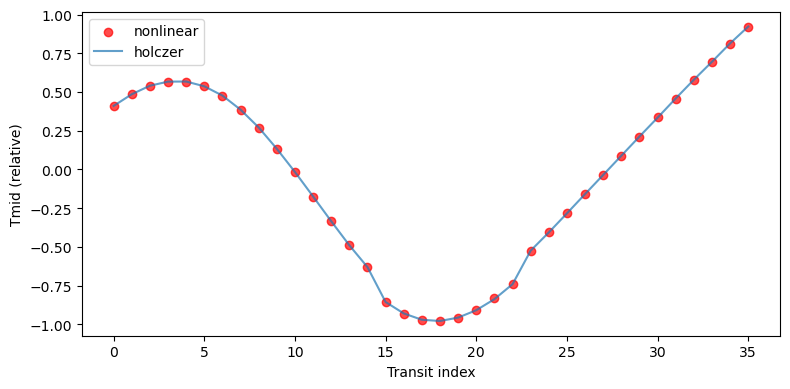

In [56]:
###plot time from linear ephemeris
best_tmids_nonlinear = nonlinear_results["nonlinear_best_psi_samp"]

x = np.arange(len(best_tmids_nonlinear))
nstd = 2

plt.figure(figsize=(8, 4))

plt.scatter(
    x, best_tmids_nonlinear,  alpha=0.7, label="nonlinear", c = 'r'
)

plt.plot(
    x, tmid_relative_holczer,  alpha=0.7, label="holczer"
)
# plt.errorbar(
#     x, best_tmids_linear, yerr=nstd*tts_l_err,
#     fmt='-o', capsize=3, alpha=0.7, label="linear"
# )


plt.xlabel("Transit index")
plt.ylabel("Tmid (relative)")
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/rp/xh33z9wx4hnf30jy15q1lvmh0000gn/T/ipykernel_81506/2731742653.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 4))


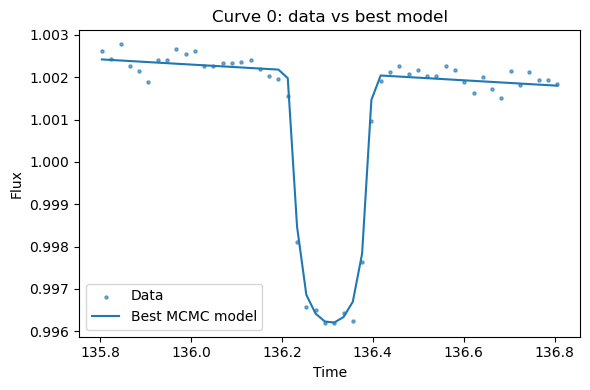

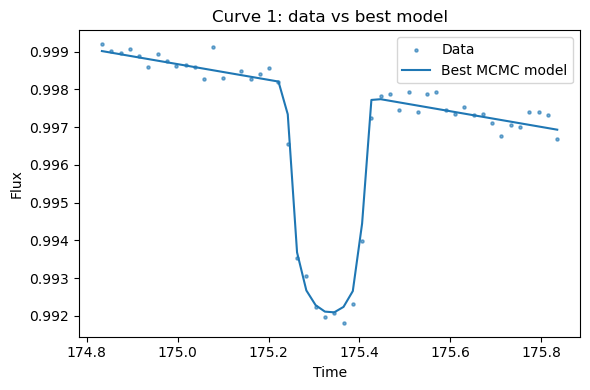

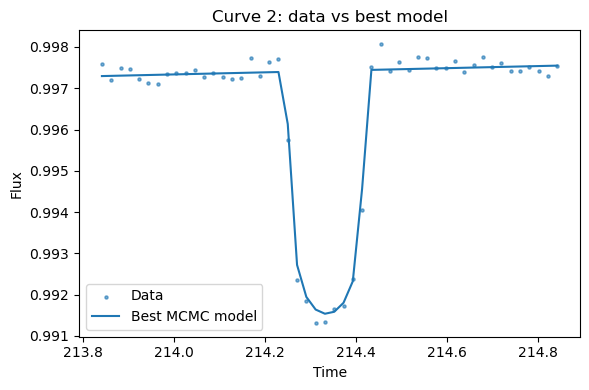

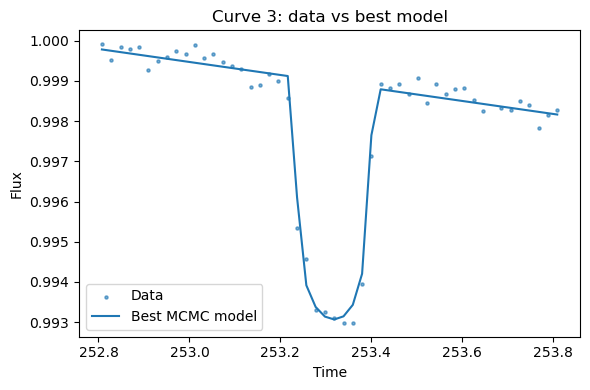

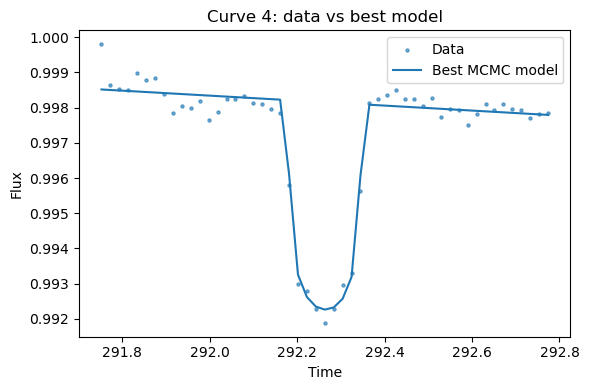

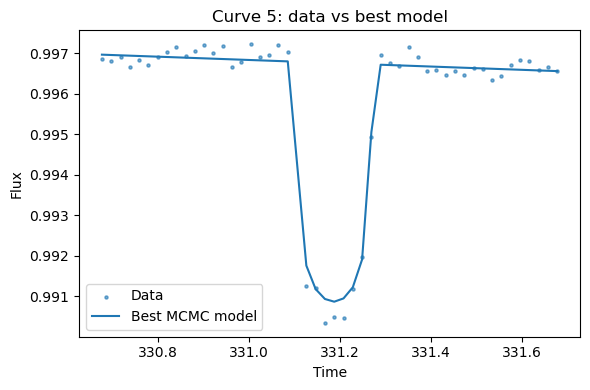

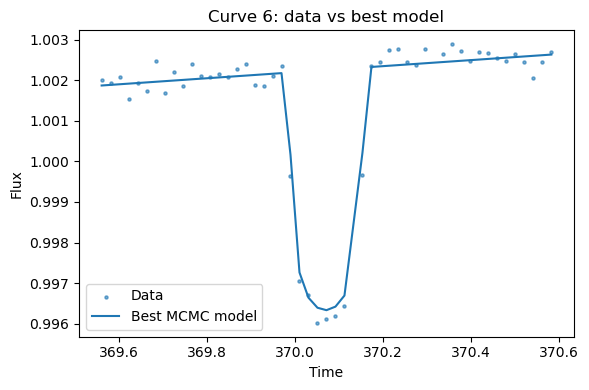

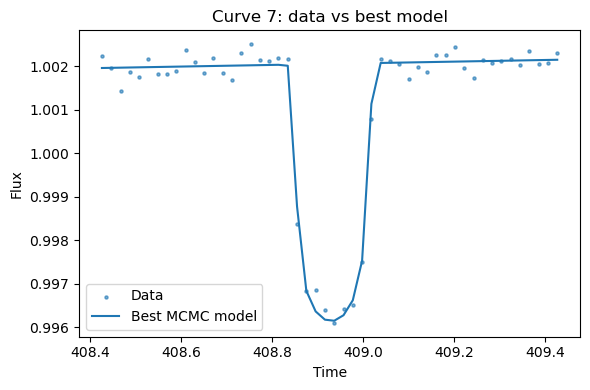

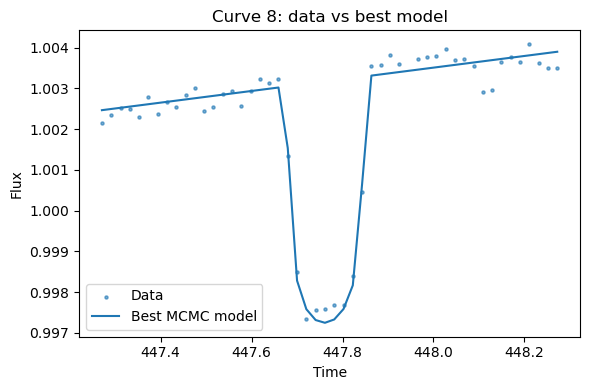

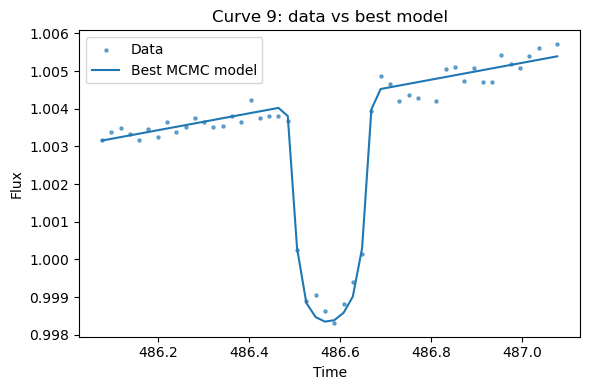

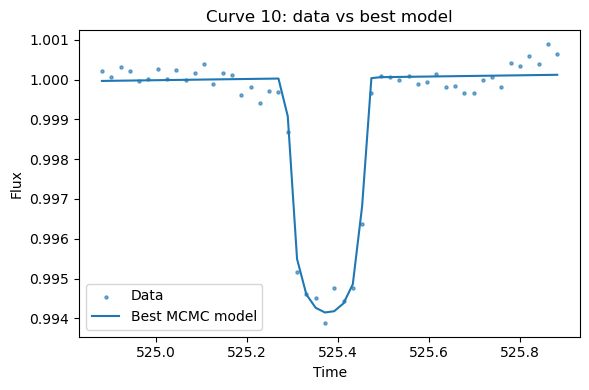

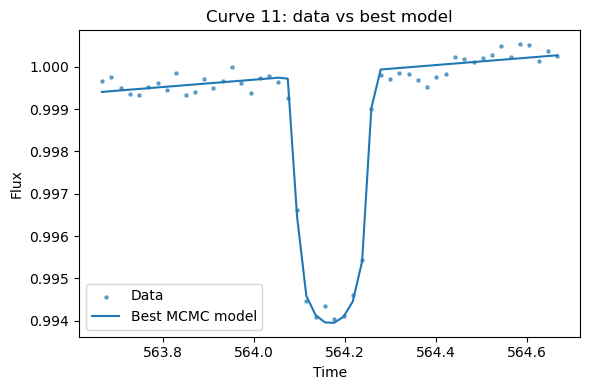

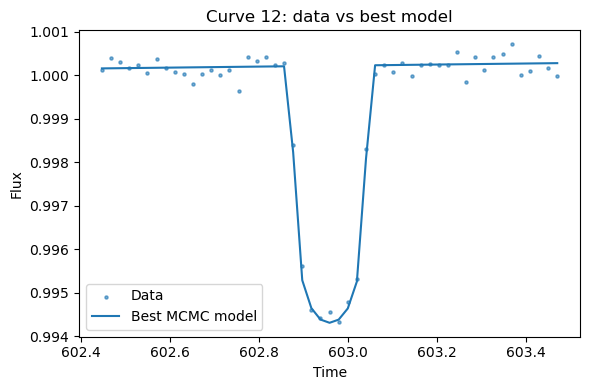

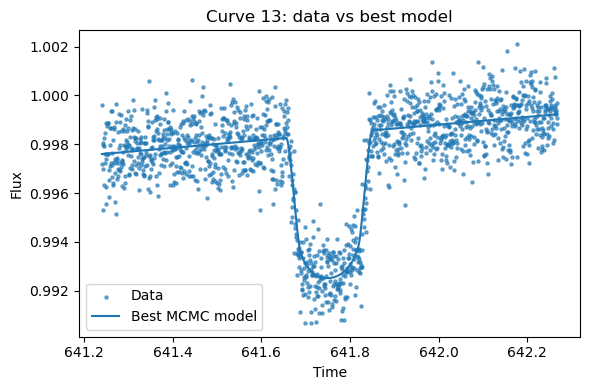

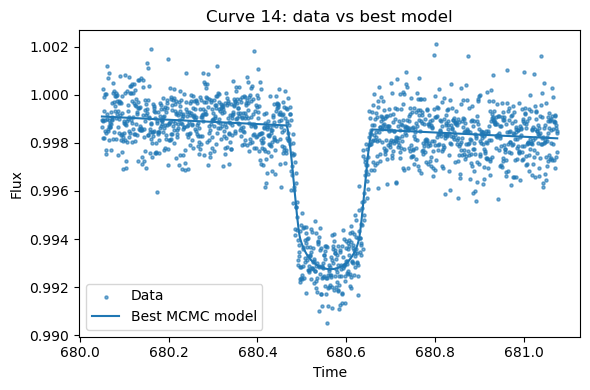

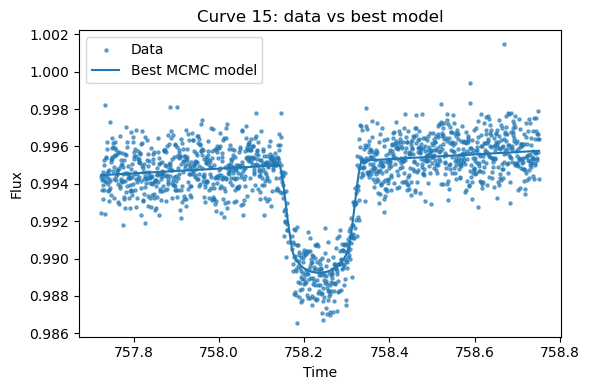

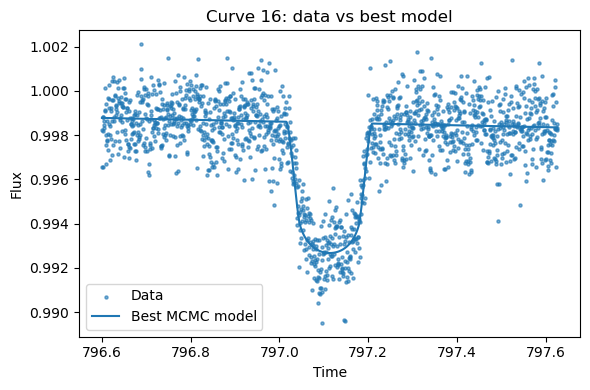

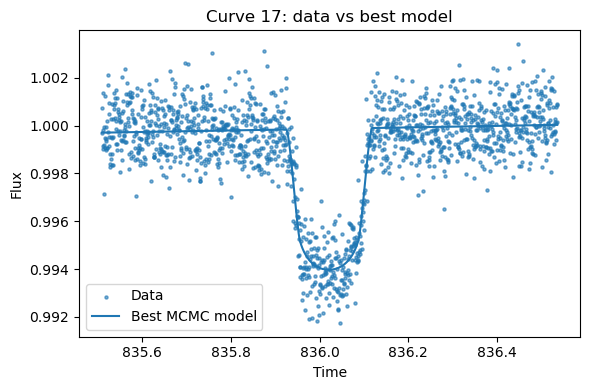

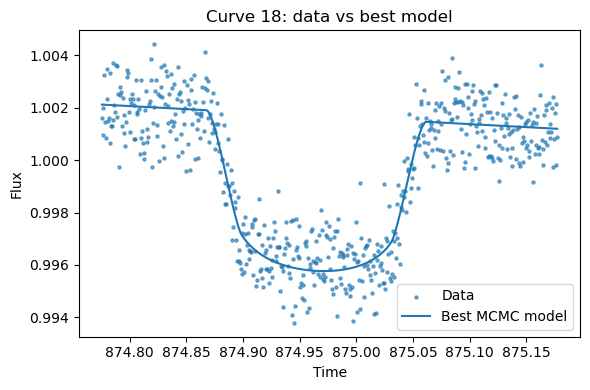

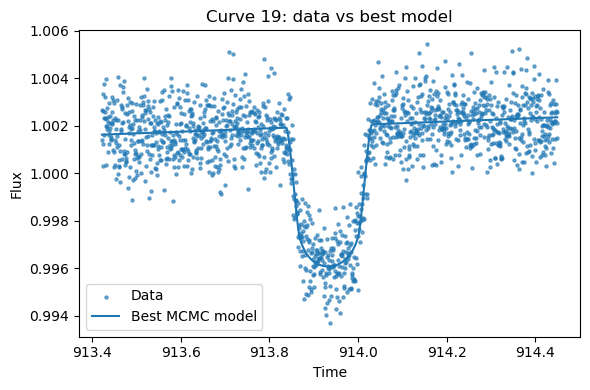

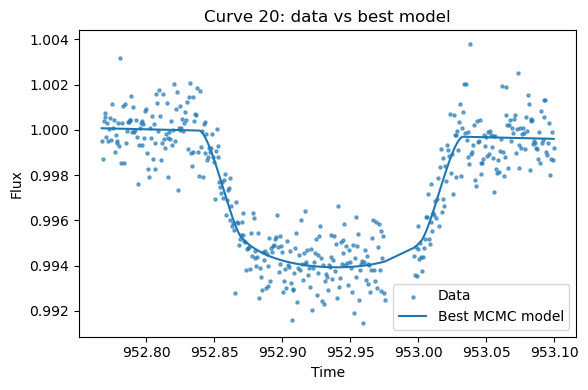

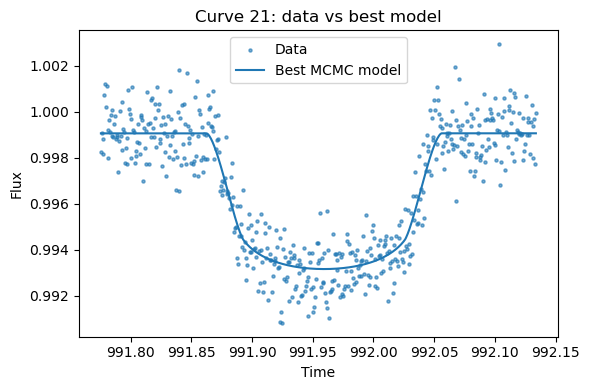

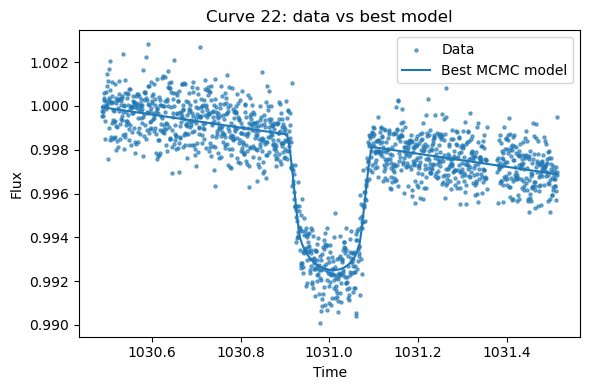

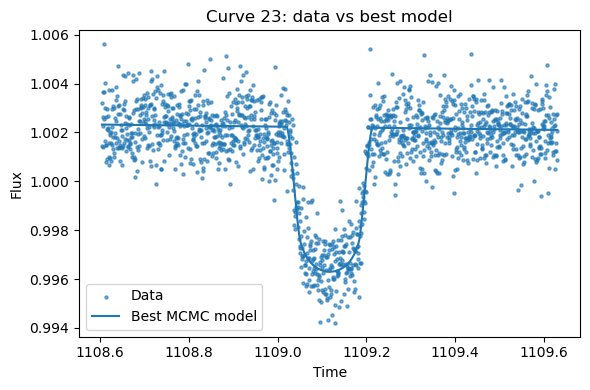

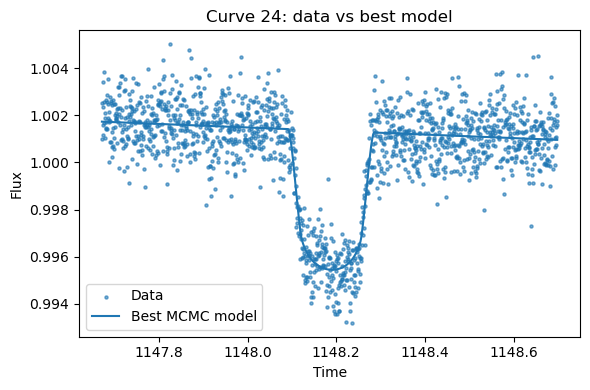

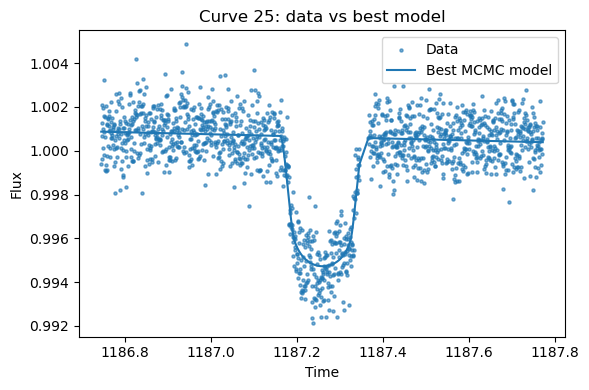

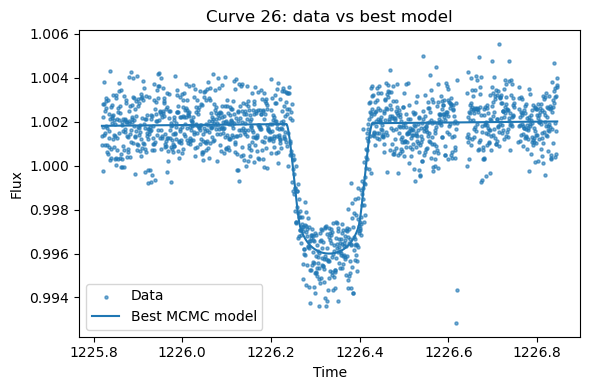

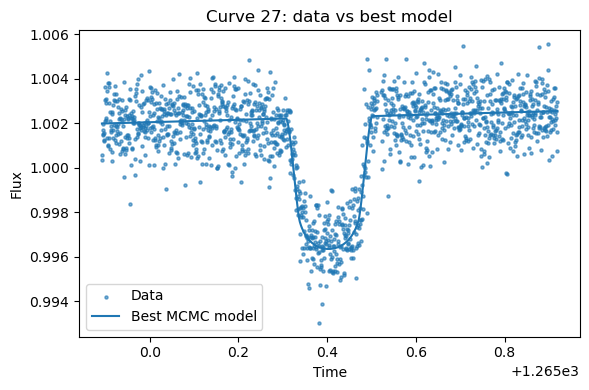

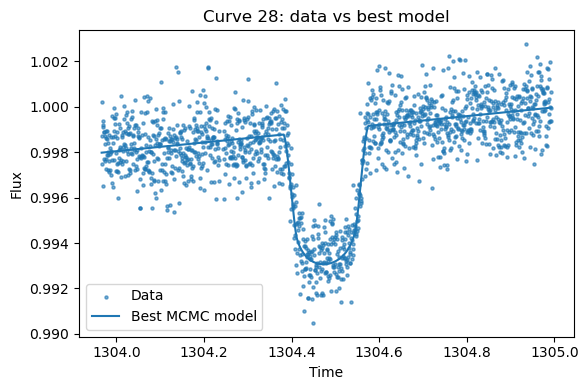

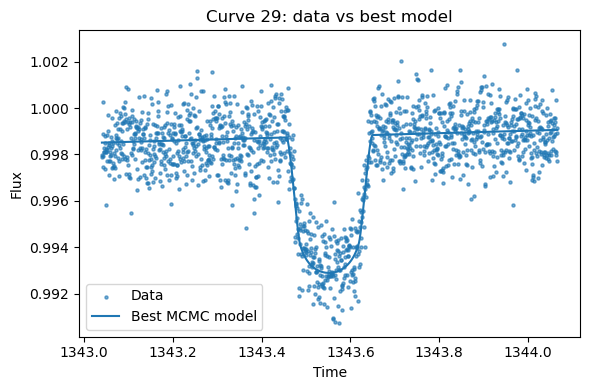

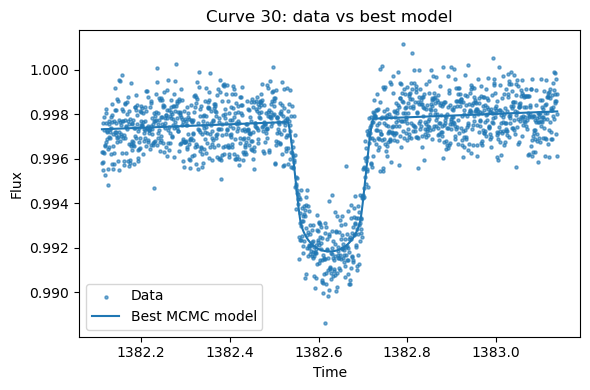

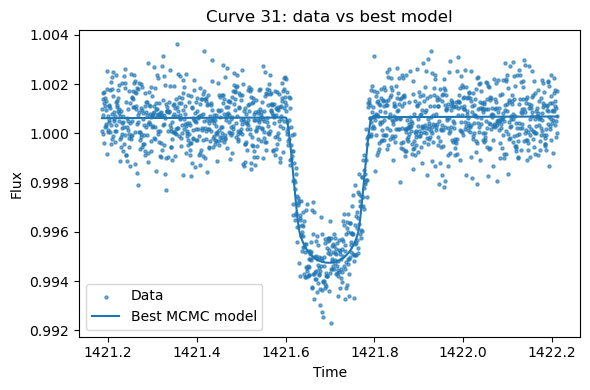

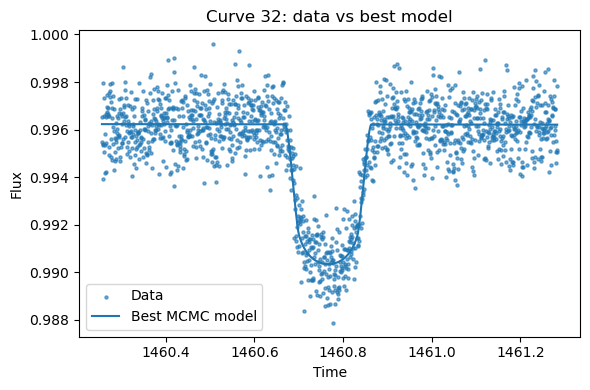

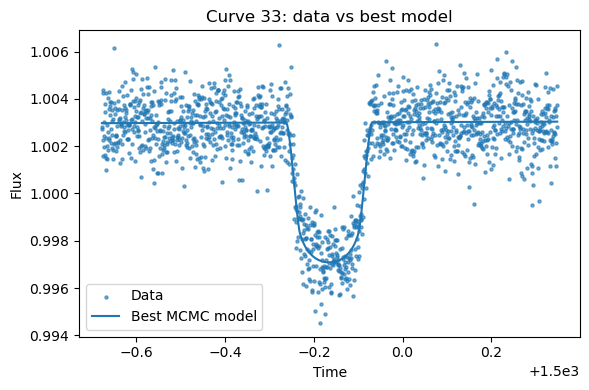

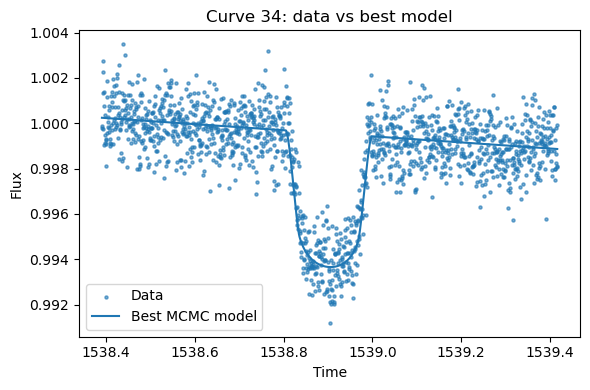

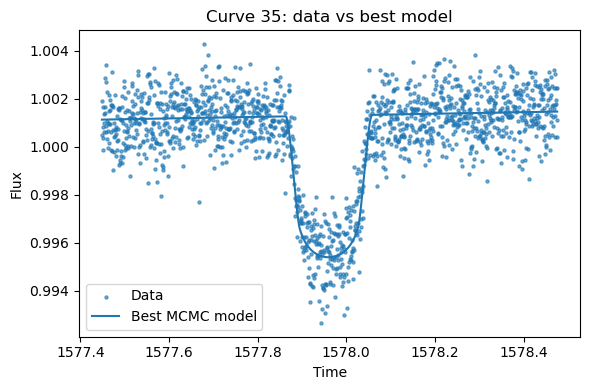

In [32]:
best_flux_prof = nonlinear_results["best_flux_prof"]
for i, curve, in enumerate(curves):
    t = curve["t"]
    flux_data = curve["flux"]
    plt.figure(figsize=(6, 4))
    plt.scatter(t, flux_data, s=5, alpha=0.6, label="Data")
    plt.plot(t, best_flux_prof[i], lw=1.5, label="Best MCMC model")
    plt.xlabel("Time")
    plt.ylabel("Flux")
    plt.title(f"Curve {i}: data vs best model")
    plt.legend()
    plt.tight_layout()

In [37]:
# --- LINEAR TMID HISTOGRAMS ONLY ---

ncurves = info["ncurves"]

tmid_lin_samples = np.vstack([
    tmids_linephem[i] + linear_posterior.posterior[f"tmid{i}"].values.reshape(-1)
    for i in range(ncurves)
]).T

labels = [f"tmid_{i}" for i in range(ncurves)]

fig, axes = plt.subplots(
    nrows=ncurves, ncols=1,
    figsize=(7, 2.5 * ncurves),
    sharex=False
)

if ncurves == 1:
    axes = [axes]

for i, ax in enumerate(axes):

    ax.hist(
        tmid_lin_samples[:, i],
        bins=40,
        alpha=0.7,
        density=True,
        label="linear"
    )

    # Optional truth marker
    if 'tmids_outer' in globals():
        ax.axvline(tmids_outer[i], linestyle="--", color="k")

    ax.set_ylabel(labels[i])

axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()


NameError: name 'linear_posterior' is not defined